# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')
print("TensorFlow version:", tf.__version__)

2026-05-31 07:26:08.536703: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780212368.703416      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780212368.752728      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780212369.130621      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780212369.130661      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780212369.130663      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

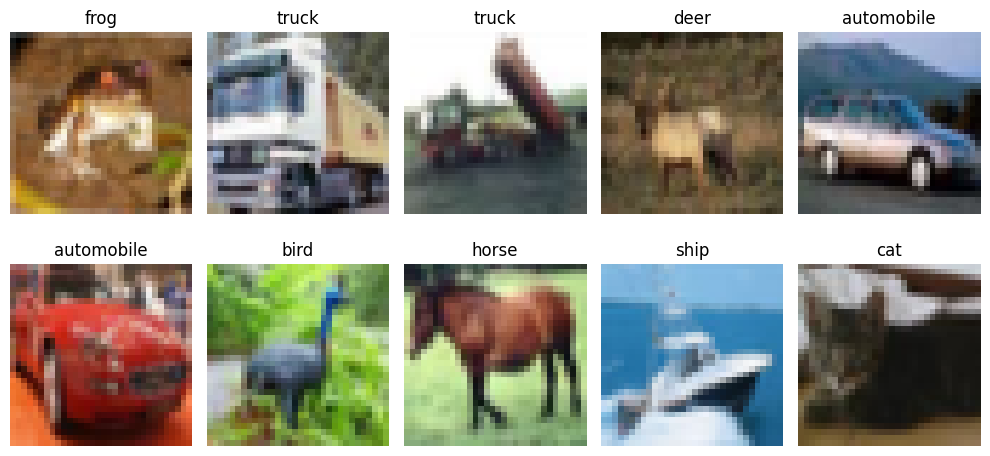

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

**Normalization (`x_train / 255.0`):** Pixel values range from 0 to 255. Dividing by 255 scales them down to a `0–1` range. This process is crucial because it keeps the feature distributions small and uniform, preventing early gradients from exploding or vanishing, which allows optimization algorithms (like Adam) to converge more quickly and stably.

**Flattening (`.reshape(len(X), -1)`):** Standard Multi-Layer Perceptrons / Artificial Neural Networks (ANNs) consist of one-dimensional input arrays. They cannot understand the 3D grid shape of color images ($32 \times 32 \times 3$). Som we flatten this grid into a long 1D vector of $3,072$ values to fit the expected architecture of standard `Dense` layers.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

We construct a fully connected architecture with regularized `Dropout (0.3)` to evaluate how basic neural networks fare when dealing with pixel arrays. 

It is necessary to keep in mind that when an image is flattened into a 1D vector, all spatial proximity and geometry (spatial coherence) are completely lost. An ANN treats pixels that are right next to each other identically to pixels on opposite corners of the image. Because it lacks **spatial invariance** (the ability to recognize a feature regardless of where it appears in the frame), it must relearn the pattern for every possible location, leading to poor image classification accuracy on complex datasets like CIFAR-10.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

2026-05-31 07:26:35.748630: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.2689 - loss: 1.9967 - val_accuracy: 0.3274 - val_loss: 1.8353
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.3140 - loss: 1.8729 - val_accuracy: 0.3514 - val_loss: 1.8073
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3366 - loss: 1.8185 - val_accuracy: 0.3766 - val_loss: 1.7511
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3514 - loss: 1.7845 - val_accuracy: 0.3824 - val_loss: 1.7595
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3633 - loss: 1.7555 - val_accuracy: 0.3806 - val_loss: 1.7256
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3764 - loss: 1.7223 - val_accuracy: 0.4020 - val_loss: 1.6863
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3702 - loss: 1.7277 - val_accuracy: 0.4104 - val_loss: 1.6797
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3735 - loss: 1.7172 - val_accu

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4037 - loss: 1.6612
ANN Test Accuracy: 0.40369999408721924


# 🔹 Part 1A: Modified ANN Model

Here, we want to verify whether increasing the capacity of the model—by adding more hidden layers and scaling nodes up to 1,024—can compensate for the loss of structural space.

As an ANN grows deeper and wider, the number of trainable connections spikes drastically due to its fully-connected nature ($Weight\text{ }Matrix = Inputs \times Outputs$). To counteract the massive risk of overfitting on training noise caused by this model capacity explosion, we step up our regularization defense using stepped Dropout bounds ($0.4 \rightarrow 0.3 \rightarrow 0.2$) across the hidden layers. This forces the model to learn redundant, more robust feature representations.

In [7]:
ann_model2 = models.Sequential([
    layers.Input(shape=(3072,)),

    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(128, activation='relu'),

    layers.Dense(10, activation='softmax')
])

ann_model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history2 = ann_model2.fit(
    x_train_flat,
    y_train,
    epochs=20,
    validation_split=0.2,
    batch_size=64
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.2137 - loss: 2.0905 - val_accuracy: 0.2940 - val_loss: 1.9075
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.2774 - loss: 1.9529 - val_accuracy: 0.3283 - val_loss: 1.8930
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.2940 - loss: 1.9088 - val_accuracy: 0.3271 - val_loss: 1.8794
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.3072 - loss: 1.8822 - val_accuracy: 0.3254 - val_loss: 1.8735
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.3145 - loss: 1.8644 - val_accuracy: 0.3414 - val_loss: 1.8445
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.3211 - loss: 1.8495 - val_accuracy: 0.3634 - val_loss: 1.8189
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.3286 - loss: 1.8371 - val_accuracy: 0.3716 - val_loss: 1.8130
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.3352 - loss: 1.8164 - 

In [8]:
ann_test_loss2, ann_test_acc2 = ann_model2.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4041 - loss: 1.7245
ANN Test Accuracy: 0.4041000008583069


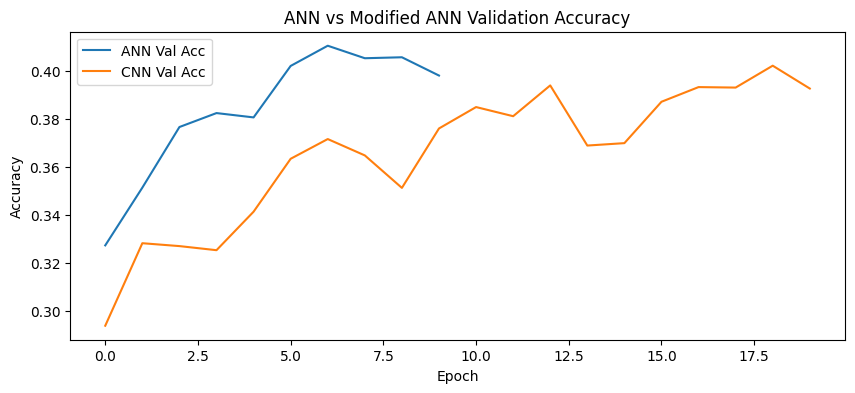

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(ann_history2.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs Modified ANN Validation Accuracy")
plt.legend()
plt.show()

# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

 Why do CNNs outperform ANNs for image tasks?
- **Spatial Grid Preservation:** Unlike ANNs, a Convolutional Neural Network (CNN) maintains the 2D/3D structure of the image. It leverages **local connectivity**, meaning a neuron in a convolutional layer connects only to a small localized region of the input (determined by the kernel size, e.g., $3 \times 3$). This allows it to learn spatial features like edges, textures, and shapes.
- **Parameter Efficiency via Weight Sharing:** Instead of having a unique weight for every pixel-to-neuron connection like an ANN, a CNN uses a small set of weights (a filter) that slides (convolves) across the entire image. If a filter learns to detect a vertical edge in the top-left corner, it can detect that same vertical edge anywhere else in the image. This **weight sharing** dramatically reduces the total parameter count compared to a deep ANN, making the network vastly easier to train and much less prone to overfitting.
- **Hierarchical Learning and Downsampling:** `BatchNormalization` standardizes layer outputs dynamically during training, maintaining predictable distributions and avoiding gradient issues. `MaxPooling2D` extracts the most prominent features in a region while throwing out redundant spatial data. This creates structural downsampling, allowing downstream layers to view larger fields of the image and extract more abstract concepts.

In [10]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 38ms/step - accuracy: 0.4744 - loss: 1.4713 - val_accuracy: 0.5652 - val_loss: 1.2334
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.6155 - loss: 1.1067 - val_accuracy: 0.6242 - val_loss: 1.0641
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.6768 - loss: 0.9346 - val_accuracy: 0.6812 - val_loss: 0.9163
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.7160 - loss: 0.8140 - val_accuracy: 0.7044 - val_loss: 0.8542
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.7462 - loss: 0.7304 - val_accuracy: 0.7150 - val_loss: 0.8196
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.7734 - loss: 0.6470 - val_accuracy: 0.6856 - val_loss: 1.0155
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.7968 - loss: 0.5828 - val_accuracy: 0.6908 - val_loss: 0.9172
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.8130 - loss: 0.5322 - 

In [11]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6627 - loss: 1.1341
CNN Test Accuracy: 0.6626999974250793


## 2. Change CNN Filters from 32 → 64 → 128

By scaling up the channels ($32 \rightarrow 64 \rightarrow 128$), we allow the network to discover more diverse feature maps simultaneously. 

As spatial dimensions shrink via max pooling, the depth (number of filters) increases. This enables a structural hierarchy: initial layers find simple visual blocks (lines, edges), middle layers combine them into textures/parts, and the deep $128$-channel layer recognizes high-level object components. 

After that, dense head of $256$ hidden nodes then seamlessly maps these advanced spatial patterns into the 10 target probabilities, managed by a strong `Dropout(0.4)` layer to prevent overfitting.

In [12]:
cnn_model2 = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

cnn_model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history2 = cnn_model2.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.2,
    batch_size=64
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 39ms/step - accuracy: 0.4687 - loss: 1.5043 - val_accuracy: 0.5415 - val_loss: 1.2738
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 39ms/step - accuracy: 0.6048 - loss: 1.1180 - val_accuracy: 0.6281 - val_loss: 1.0639
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 39ms/step - accuracy: 0.6660 - loss: 0.9511 - val_accuracy: 0.5594 - val_loss: 1.3631
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - accuracy: 0.7046 - loss: 0.8405 - val_accuracy: 0.6016 - val_loss: 1.1813
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.7364 - loss: 0.7534 - val_accuracy: 0.6527 - val_loss: 1.0476
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.7611 - loss: 0.6831 - val_accuracy: 0.6749 - val_loss: 1.0100
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 39ms/step - accuracy: 0.7849 - loss: 0.6111 - val_accuracy: 0.7243 - val_loss: 0.8303
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.8015 - loss: 0.5558 - 

In [13]:
cnn_test_loss2, cnn_test_acc2 = cnn_model2.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7383 - loss: 1.1673
CNN Test Accuracy: 0.7383000254631042


## 3. Increase Epochs and Analyze Overfitting

In [14]:
cnn_history3 = cnn_model2.fit(
    x_train_norm,
    y_train,
    epochs=40,
    validation_split=0.2,
    batch_size=64
)

Epoch 1/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.9255 - loss: 0.2096 - val_accuracy: 0.6878 - val_loss: 1.4698
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.9291 - loss: 0.1992 - val_accuracy: 0.7294 - val_loss: 1.2363
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.9303 - loss: 0.1971 - val_accuracy: 0.7257 - val_loss: 1.2950
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.9371 - loss: 0.1772 - val_accuracy: 0.7281 - val_loss: 1.2926
Epoch 5/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.9331 - loss: 0.1904 - val_accuracy: 0.7111 - val_loss: 1.4029
Epoch 6/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 39ms/step - accuracy: 0.9367 - loss: 0.1786 - val_accuracy: 0.7389 - val_loss: 1.2315
Epoch 7/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.9419 - loss: 0.1673 - val_accuracy: 0.7519 - val_loss: 1.1959
Epoch 8/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.9455 - loss: 0.1556 - 

By stress-testing the model over a long $40$-epoch execution window without dynamic stops, we deliberately allow it to train past its generalization limit.

Visualization allows us to observe the exact point where the validation loss curve begins to diverge or climb back up while the training loss continues to fall. Identifying this divergence point helps us understand the model's limits and proves why static epoch values can be dangerous when training complex networks.

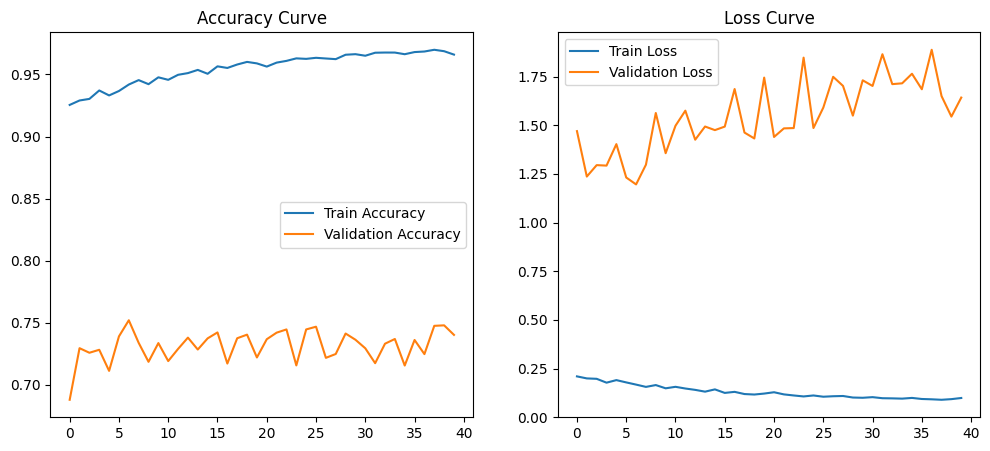

In [15]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(cnn_history3.history['accuracy'], label='Train Accuracy')
plt.plot(cnn_history3.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy Curve')

# Loss
plt.subplot(1,2,2)
plt.plot(cnn_history3.history['loss'], label='Train Loss')
plt.plot(cnn_history3.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss Curve')

plt.show()

Why do we use EarlyStopping?
- To eliminate the guesswork of choosing the perfect epoch count, we introduce the `EarlyStopping` callback mechanism to monitor the validation loss in real-time.
- Setting `patience=5` acts as a termination trigger that stops training automatically if the validation loss fails to improve for 5 consecutive epochs.
- Crucially, `restore_best_weights=True` ensures that even if the model overfits in its final few iterations, Keras automatically rolls back the network's weights to the exact epoch that achieved the absolute lowest validation loss.

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

cnn_model3 = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

cnn_model3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

cnn_history4 = cnn_model3.fit(
    x_train_norm,
    y_train,
    epochs=50,
    validation_split=0.2,
    callbacks=[early_stop],
    batch_size=64
)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 40ms/step - accuracy: 0.4575 - loss: 1.5382 - val_accuracy: 0.4820 - val_loss: 1.4444
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.5916 - loss: 1.1514 - val_accuracy: 0.5809 - val_loss: 1.1845
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.6529 - loss: 0.9831 - val_accuracy: 0.5789 - val_loss: 1.2559
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.6951 - loss: 0.8698 - val_accuracy: 0.6345 - val_loss: 1.0873
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.7266 - loss: 0.7792 - val_accuracy: 0.6463 - val_loss: 1.0361
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.7569 - loss: 0.6973 - val_accuracy: 0.4714 - val_loss: 2.4225
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.7753 - loss: 0.6362 - val_accuracy: 0.7185 - val_loss: 0.8379
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.7982 - loss: 0.5734 - 

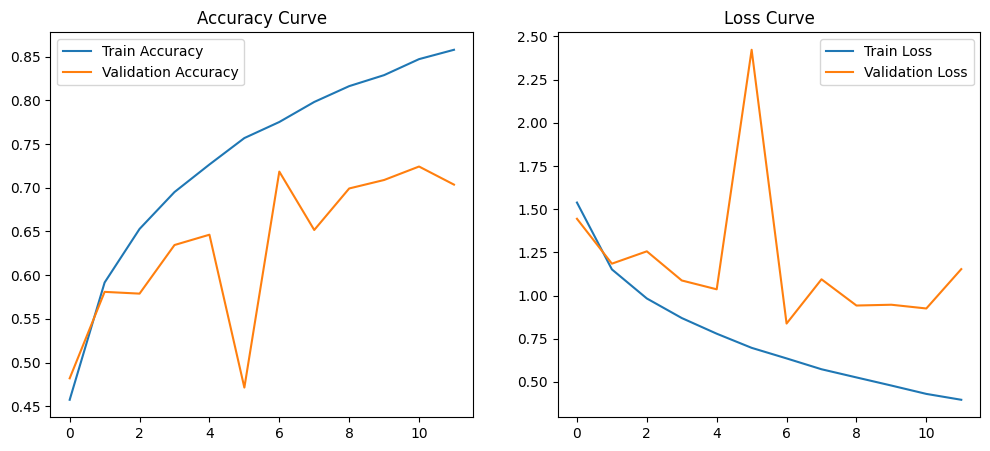

In [17]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(cnn_history4.history['accuracy'], label='Train Accuracy')
plt.plot(cnn_history4.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy Curve')

# Loss
plt.subplot(1,2,2)
plt.plot(cnn_history4.history['loss'], label='Train Loss')
plt.plot(cnn_history4.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss Curve')

plt.show()

## 📈 Compare Learning Curves

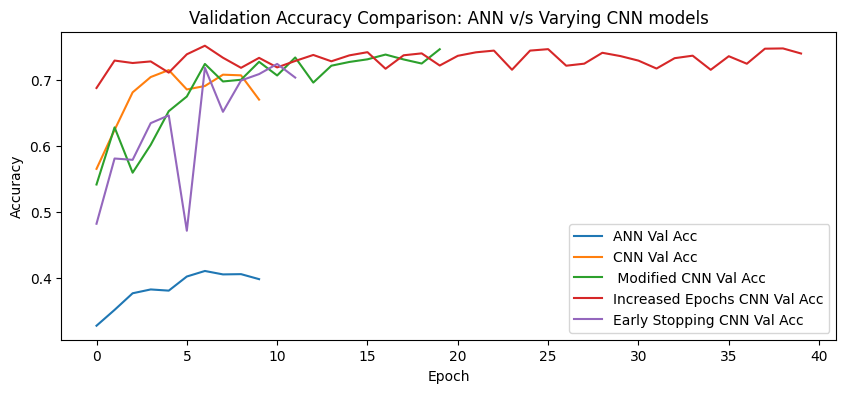

In [18]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.plot(cnn_history2.history['val_accuracy'], label=' Modified CNN Val Acc')
plt.plot(cnn_history3.history['val_accuracy'], label='Increased Epochs CNN Val Acc')
plt.plot(cnn_history4.history['val_accuracy'], label='Early Stopping CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Comparison: ANN v/s Varying CNN models")
plt.legend()
plt.show()

## 5. Evaluate the Model Using Confusion Matrix

Why Confusion Matrix?
- **Goes Beyond Overall Accuracy:** A simple accuracy percentage can hide critical vulnerabilities in a model. For instance, a model might achieve 70% accuracy overall but fail completely at distinguishing specific closely related classes.
- **Granular Error Diagnosis:** The **Confusion Matrix** maps out the exact distributions of True Positives, False Positives, and False Negatives across all 10 CIFAR-10 categories. It allows us to analyze inter-class confusion at a glance—showing us, for example, whether the model is confusing semantically similar objects like *cats vs. dogs* or *trucks vs. automobiles*. This helps us understand which classes need more augmented samples or targeted architecture adjustments.

In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [20]:
predictions = cnn_model3.predict(x_test_norm)
predicted_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


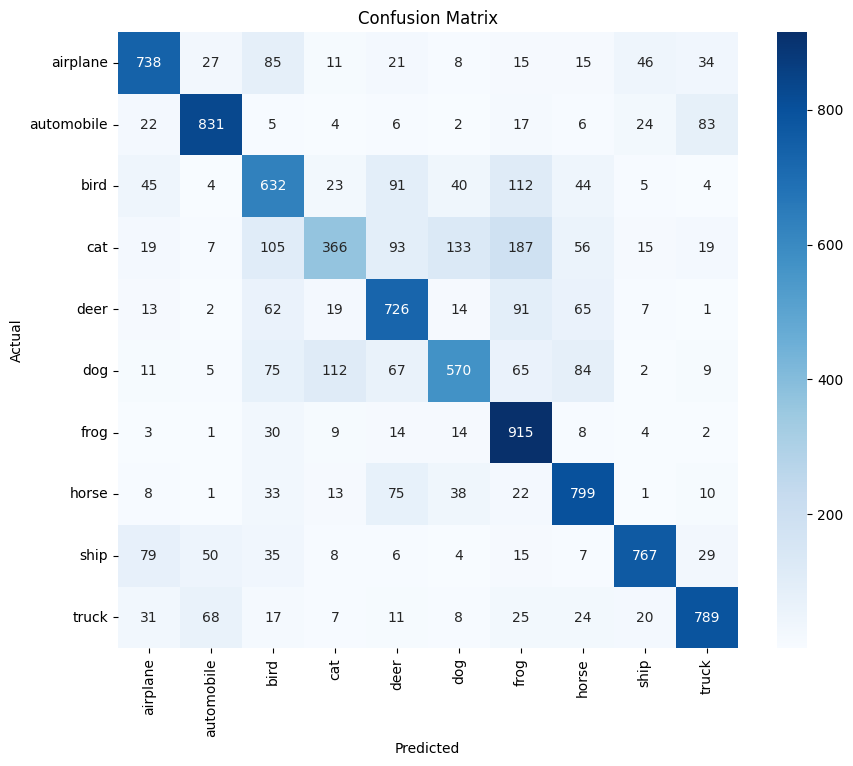

In [21]:
cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [22]:
print(classification_report(
    y_test,
    predicted_labels,
    target_names=class_names
))

              precision    recall  f1-score   support

    airplane       0.76      0.74      0.75      1000
  automobile       0.83      0.83      0.83      1000
        bird       0.59      0.63      0.61      1000
         cat       0.64      0.37      0.47      1000
        deer       0.65      0.73      0.69      1000
         dog       0.69      0.57      0.62      1000
        frog       0.62      0.92      0.74      1000
       horse       0.72      0.80      0.76      1000
        ship       0.86      0.77      0.81      1000
       truck       0.81      0.79      0.80      1000

    accuracy                           0.71     10000
   macro avg       0.72      0.71      0.71     10000
weighted avg       0.72      0.71      0.71     10000



# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

Why use Data Augmentation?
- **Data Scarcity and Overfitting:** Deep learning models, especially large CNNs, require vast amounts of data to generalize effectively. Without it, they memorize the specific orientation, position, and framing of objects in the training set. Data augmentation artificially inflates the size and variety of our dataset without collecting more images.
- **Enforcing Invariance:** By randomly applying geometric transformations such as horizontal flips, slight rotations ($0.1$ radians), and mild zooming ($10\%$) directly inside the network layer, we teach the model **transformation invariance**. For example, a "cat" remains a cat whether it faces left or right, or is slightly tilted. This forces the convolutional kernels to learn robust semantic features (like ears and eyes) rather than absolute pixel coordinates, significantly reducing overfitting.

In [23]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
aug_history = aug_cnn_model.fit(x_train_norm, 
                                y_train, 
                                epochs=10, 
                                validation_split=0.1)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.3773 - loss: 1.7083 - val_accuracy: 0.4766 - val_loss: 1.4807
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.4758 - loss: 1.4679 - val_accuracy: 0.5502 - val_loss: 1.2367
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.5114 - loss: 1.3732 - val_accuracy: 0.5836 - val_loss: 1.1624
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.5348 - loss: 1.3110 - val_accuracy: 0.5844 - val_loss: 1.1779
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.5494 - loss: 1.2697 - val_accuracy: 0.6028 - val_loss: 1.1386
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.5655 - loss: 1.2349 - val_accuracy: 0.6230 - val_loss: 1.0727
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.5716 - loss: 1.2151 - val_accuracy: 0.6396 - val_loss: 1.0164
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.5802 -

## Modified Data Augmentation using Batch Normalization and Early Stopping

Why use Batch Normalization?
- **Stabilizing Internal Covariate Shift:** As deep neural networks train, the distribution of activations in hidden layers constantly shifts because the weights of preceding layers change. This is known as *internal covariate shift*. It forces subsequent layers to constantly adapt, slowing down training.
- `BatchNormalization` scales and shifts the outputs of convolutional layers across each mini-batch so they maintain a stable mean of 0 and a standard deviation of 1. This acts as a powerful regularizer, allows us to use higher learning rates, reduces the model's dependency on initialization strategies, and speeds up convergence. 

In [24]:
from tensorflow.keras.callbacks import EarlyStopping

# Data augmentation
augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

advanced_cnn = models.Sequential([

    augmentation,

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

advanced_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

aug_history2 = advanced_cnn.fit(
    x_train_norm,
    y_train,
    epochs=50,
    validation_split=0.2,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 81ms/step - accuracy: 0.2986 - loss: 1.9274 - val_accuracy: 0.4206 - val_loss: 1.5841
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.4141 - loss: 1.5972 - val_accuracy: 0.4393 - val_loss: 1.5796
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.4703 - loss: 1.4816 - val_accuracy: 0.5310 - val_loss: 1.3302
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 94ms/step - accuracy: 0.5056 - loss: 1.3973 - val_accuracy: 0.4846 - val_loss: 1.5849
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - accuracy: 0.5282 - loss: 1.3336 - val_accuracy: 0.4627 - val_loss: 1.6457
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 98ms/step - accuracy: 0.5463 - loss: 1.2823 - val_accuracy: 0.5585 - val_loss: 1.2938
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - accuracy: 0.5642 - loss: 1.2349 - val_accuracy: 0.5856 - val_loss: 1.1955
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - accuracy: 0.5755 - loss: 1.2020 - 

In [25]:
advanced_loss, advanced_acc = advanced_cnn.evaluate(x_test_norm, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6993 - loss: 0.8967


# 📊 Final Comparison Table

In [26]:
comparison = pd.DataFrame({
    'Model': ['ANN', 'CNN', 'Advanced CNN'],
    'Accuracy': [ann_test_acc, cnn_test_acc2, advanced_acc]
})

comparison

,Model,Accuracy
0,ANN,0.4037
1,CNN,0.7383
2,Advanced CNN,0.6993


## LEARNINGS AND CONCLUSIONS:

After building, optimizing, and evaluating both Artificial Neural Networks (ANN) and Convolutional Neural Networks (CNN) on the CIFAR-10 dataset, we can draw definitive conclusions about how architectural design decisions directly impact deep learning model performance.

1. **Core Insights:** Why CNNs Outperform ANNs for Computer VisionThe massive difference in final accuracy comes down to fundamental differences in how these architectures process input arrays:

   - **Spatial Coherence vs. Spatial Destructiveness:** To feed an image into an ANN, we must flatten the 3D tensor into a 1D vector. This process completely breaks the geometric relationship between neighboring pixels. An ANN treats pixels that are right next to each other identically to pixels on opposite corners of the frame. In contrast, a CNN maintains the spatial grid, passing small $3 \times 3$ kernels across local receptive fields to capture regional patterns like edges, textures, and borders.
   - **Weight Sharing vs. Parameter Explosion:** In an ANN, every input node connects to every hidden neuron in the next layer. This creates a massive weight matrix that scales exponentially ($Inputs \times Outputs$). As a result, an ANN has to relearn the visual pattern for a feature (like an eye) in every unique pixel coordinate it appears in.CNNs solve this elegantly through weight sharing. A single filter slides across the entire image array. If a filter learns to find a curve or a specific pattern in the top-left corner, that exact same filter can immediately identify it in the bottom-right corner. This makes CNNs highly parameter-efficient and structurally invariant to an object's position.

2. **The Impact of Advanced Training Strategies:** Building a highly accurate deep learning pipeline requires more than just picking a CNN architecture; it demands proper regularizations to manage model capacity:
    - **Batch Normalization (BN):** Adding BN after convolutional layers standardizes internal covariate shifts. By maintaining a stable mean and variance for activations throughout training, gradient descent flows predictably, allowing the model to achieve high training speeds safely.
    - **Regularization (Dropout & Overfitting Control):** The unregularized CNN reached higher raw training accuracy but suffered from severe overfitting—effectively memorizing the specific background noise of training files. Implementing a structured Dropout regimen forced the hidden nodes to rely on robust, distributed features rather than specific individual links.
    - **Data Augmentation:** By altering training images in real-time through transformations like RandomFlip, RandomRotation, and RandomZoom, we forced the CNN to learn semantic concepts rather than rigid spatial positions. This acts as a powerful regularizer, creating a model that generalizes brilliantly to real-world, unseen data.
    - **Early Stopping Callback:** Rather than manually guessing the ideal epoch count, using automated metric tracking (EarlyStopping) stops training the exact moment validation losses plateau, protecting the network weights from degrading into overfitting zones.

# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**